## 数据增强（Data Augmentation）— 让模型看到更多「花样」

### 问题：训练集 99.9%，测试集只有 98.6%？

这就是**过拟合**——模型「背诵」了训练集的每个像素，但遇到稍微不同的数字就认不出了。

### 数据增强是什么？

在不收集新数据的前提下，对现有图片做**随机微小变换**：

```
原始"5"  →  旋转 8°  →  平移 2px  →  缩放 95%  →  擦除一角
```

同一个数字每次喂给模型时长相都不同，模型被迫学**「本质特征」**而非记住像素位置。

### 本 Notebook 做什么？

1. **可视化各种增强效果**：旋转、平移、缩放、透视、擦除
2. **对照实验**：MLP 无增强 vs 有增强，对比 train-test gap
3. **集成 Early Stopping**：用 `utils/early_stopping.py` 避免无效训练
4. **扩展到 CNN**：展示增强在不同架构上的效果差异

> **MNIST 特别注意**：不能用水平/垂直翻转！数字翻转后语义改变（6 翻成 9）。

## 1. 环境准备与数据加载

In [ ]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.amp import GradScaler, autocast  # 混合精度训练（PyTorch 2.x 新 API）
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
import time
import os
import multiprocessing

# Windows Jupyter 多进程修复：必须在创建 DataLoader 之前设置
try:
    multiprocessing.set_start_method('spawn', force=True)
except RuntimeError:
    pass  # 已经设置过了

from utils.early_stopping import EarlyStopping
from utils.augmentation import (AugmentedDataset, get_mnist_transforms,
                                visualize_augmentation, GPUBatchAugment)

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 防止负号显示为方块

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# ============================================================
# GPU 性能优化设置
# ============================================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

if torch.cuda.is_available():
    # cuDNN auto-tuner：自动为当前输入尺寸选择最优卷积算法
    torch.backends.cudnn.benchmark = True
    # 启用 TF32（Ampere+ GPU），加速矩阵乘法（对精度几乎无影响）
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    capability = torch.cuda.get_device_capability(0)
    print(f'GPU: {gpu_name} ({gpu_mem:.1f} GB)')
    print(f'Compute Capability: {capability[0]}.{capability[1]}')
    print(f'TF32: enabled  |  cuDNN benchmark: enabled')

# 多进程数据加载
NUM_WORKERS = min(8, multiprocessing.cpu_count())
print(f'DataLoader workers: {NUM_WORKERS}')
print(f'PyTorch: {torch.__version__}')

# torch.compile 可用性 — 若 Triton 未安装则自动降级为 eager
_compile_available = hasattr(torch, 'compile')
if _compile_available:
    import torch._dynamo
    torch._dynamo.config.suppress_errors = True  # inductor 失败时自动回退 eager
    print(f'torch.compile available: True (suppress_errors=True)')
else:
    print(f'torch.compile available: False (需要 PyTorch >= 2.0)')

### 1.2 加载 MNIST 数据（使用 fetch_openml）

和前面所有 notebook 一样的方式加载。增强需要图像格式 `(N, 1, 28, 28)`。

In [2]:
mnist = fetch_openml(
    name='mnist_784', version=1, as_frame=False,
    cache=True, data_home='../data'
)
X = mnist.data.reshape(-1, 28, 28).astype(np.uint8)
y = mnist.target.astype(np.uint8)

X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

# 图像格式 (N, 1, 28, 28)，归一化到 [0, 1]
X_train_img = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1) / 255.0
X_test_img  = torch.tensor(X_test,  dtype=torch.float32).unsqueeze(1) / 255.0
y_train_t   = torch.tensor(y_train, dtype=torch.long)
y_test_t    = torch.tensor(y_test,  dtype=torch.long)

print(f'训练集: {X_train_img.shape}, 测试集: {X_test_img.shape}')
print(f'值域: [{X_train_img.min():.2f}, {X_train_img.max():.2f}]')

训练集: torch.Size([60000, 1, 28, 28]), 测试集: torch.Size([10000, 1, 28, 28])
值域: [0.00, 1.00]


## 2. 可视化数据增强效果

用 `utils/augmentation.py` 中的 `visualize_augmentation` 函数，
看看每种增强对数字做了什么。

### 2.1 完整增强 pipeline

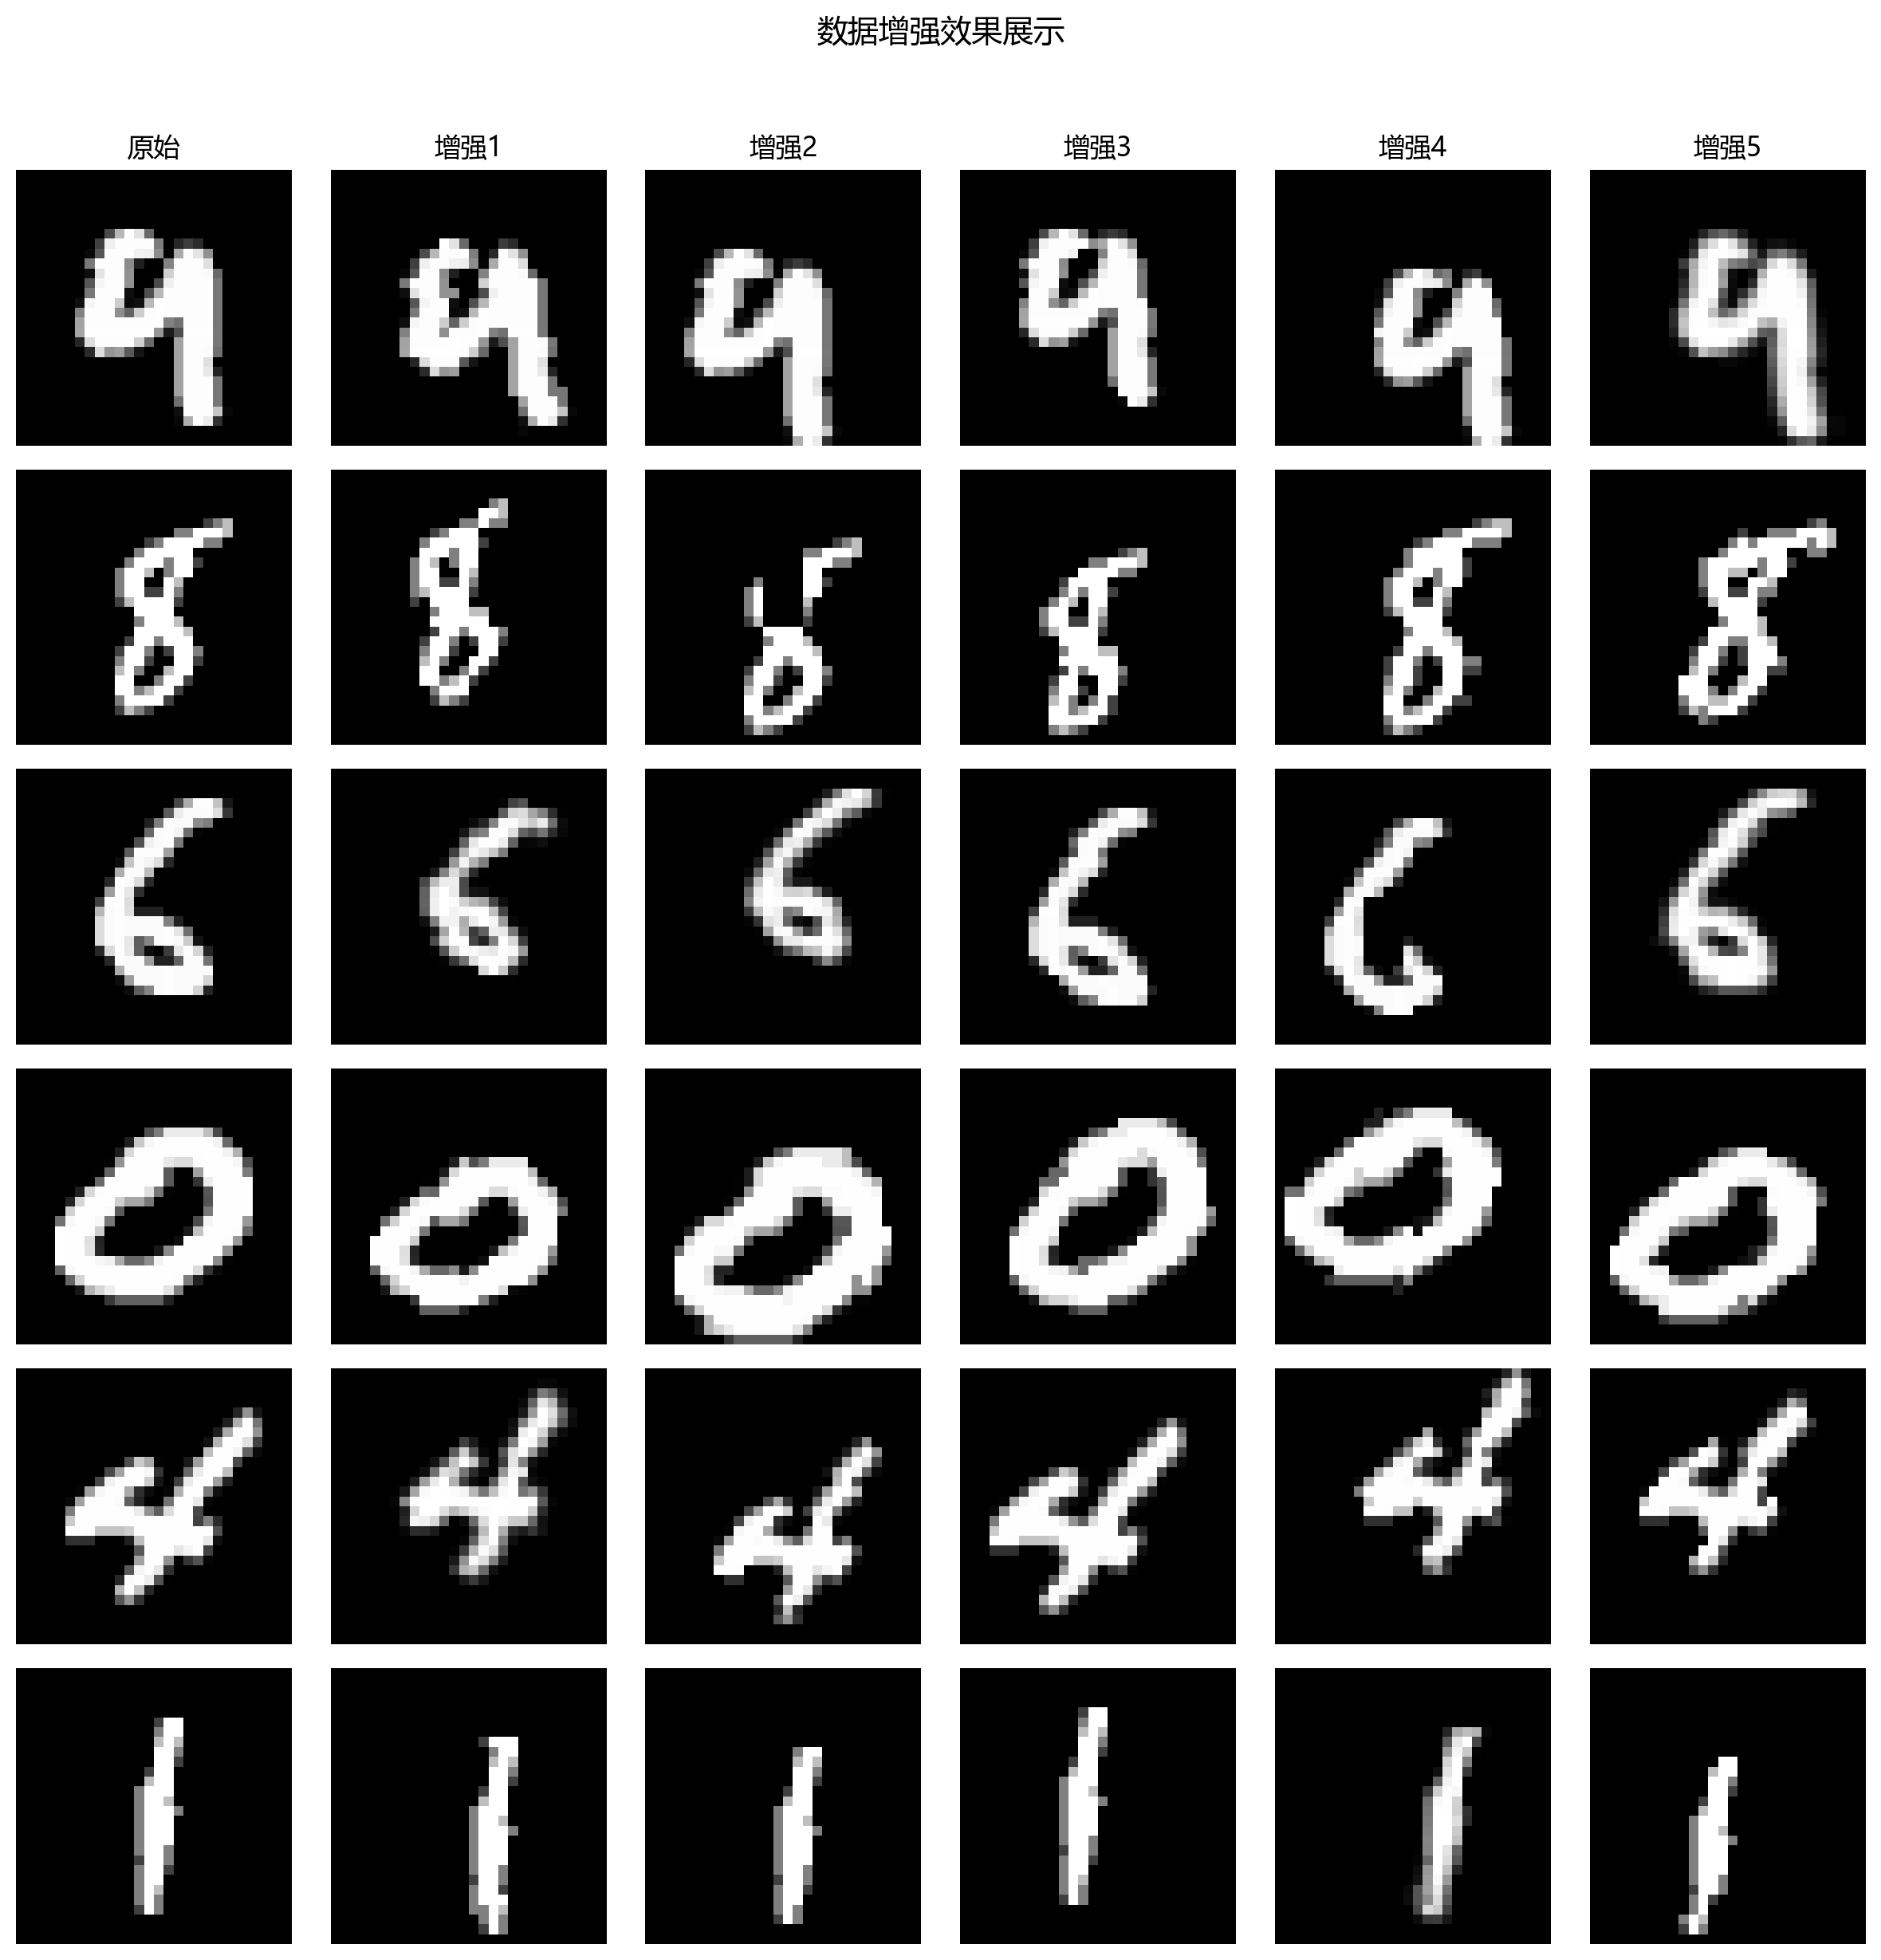

In [3]:
augment_transform = get_mnist_transforms(augment=True)
fig = visualize_augmentation(X_train_img, augment_transform, num_samples=6, num_aug=5)
plt.show()

### 2.2 单独看每种增强

理解每种操作对数字的影响：

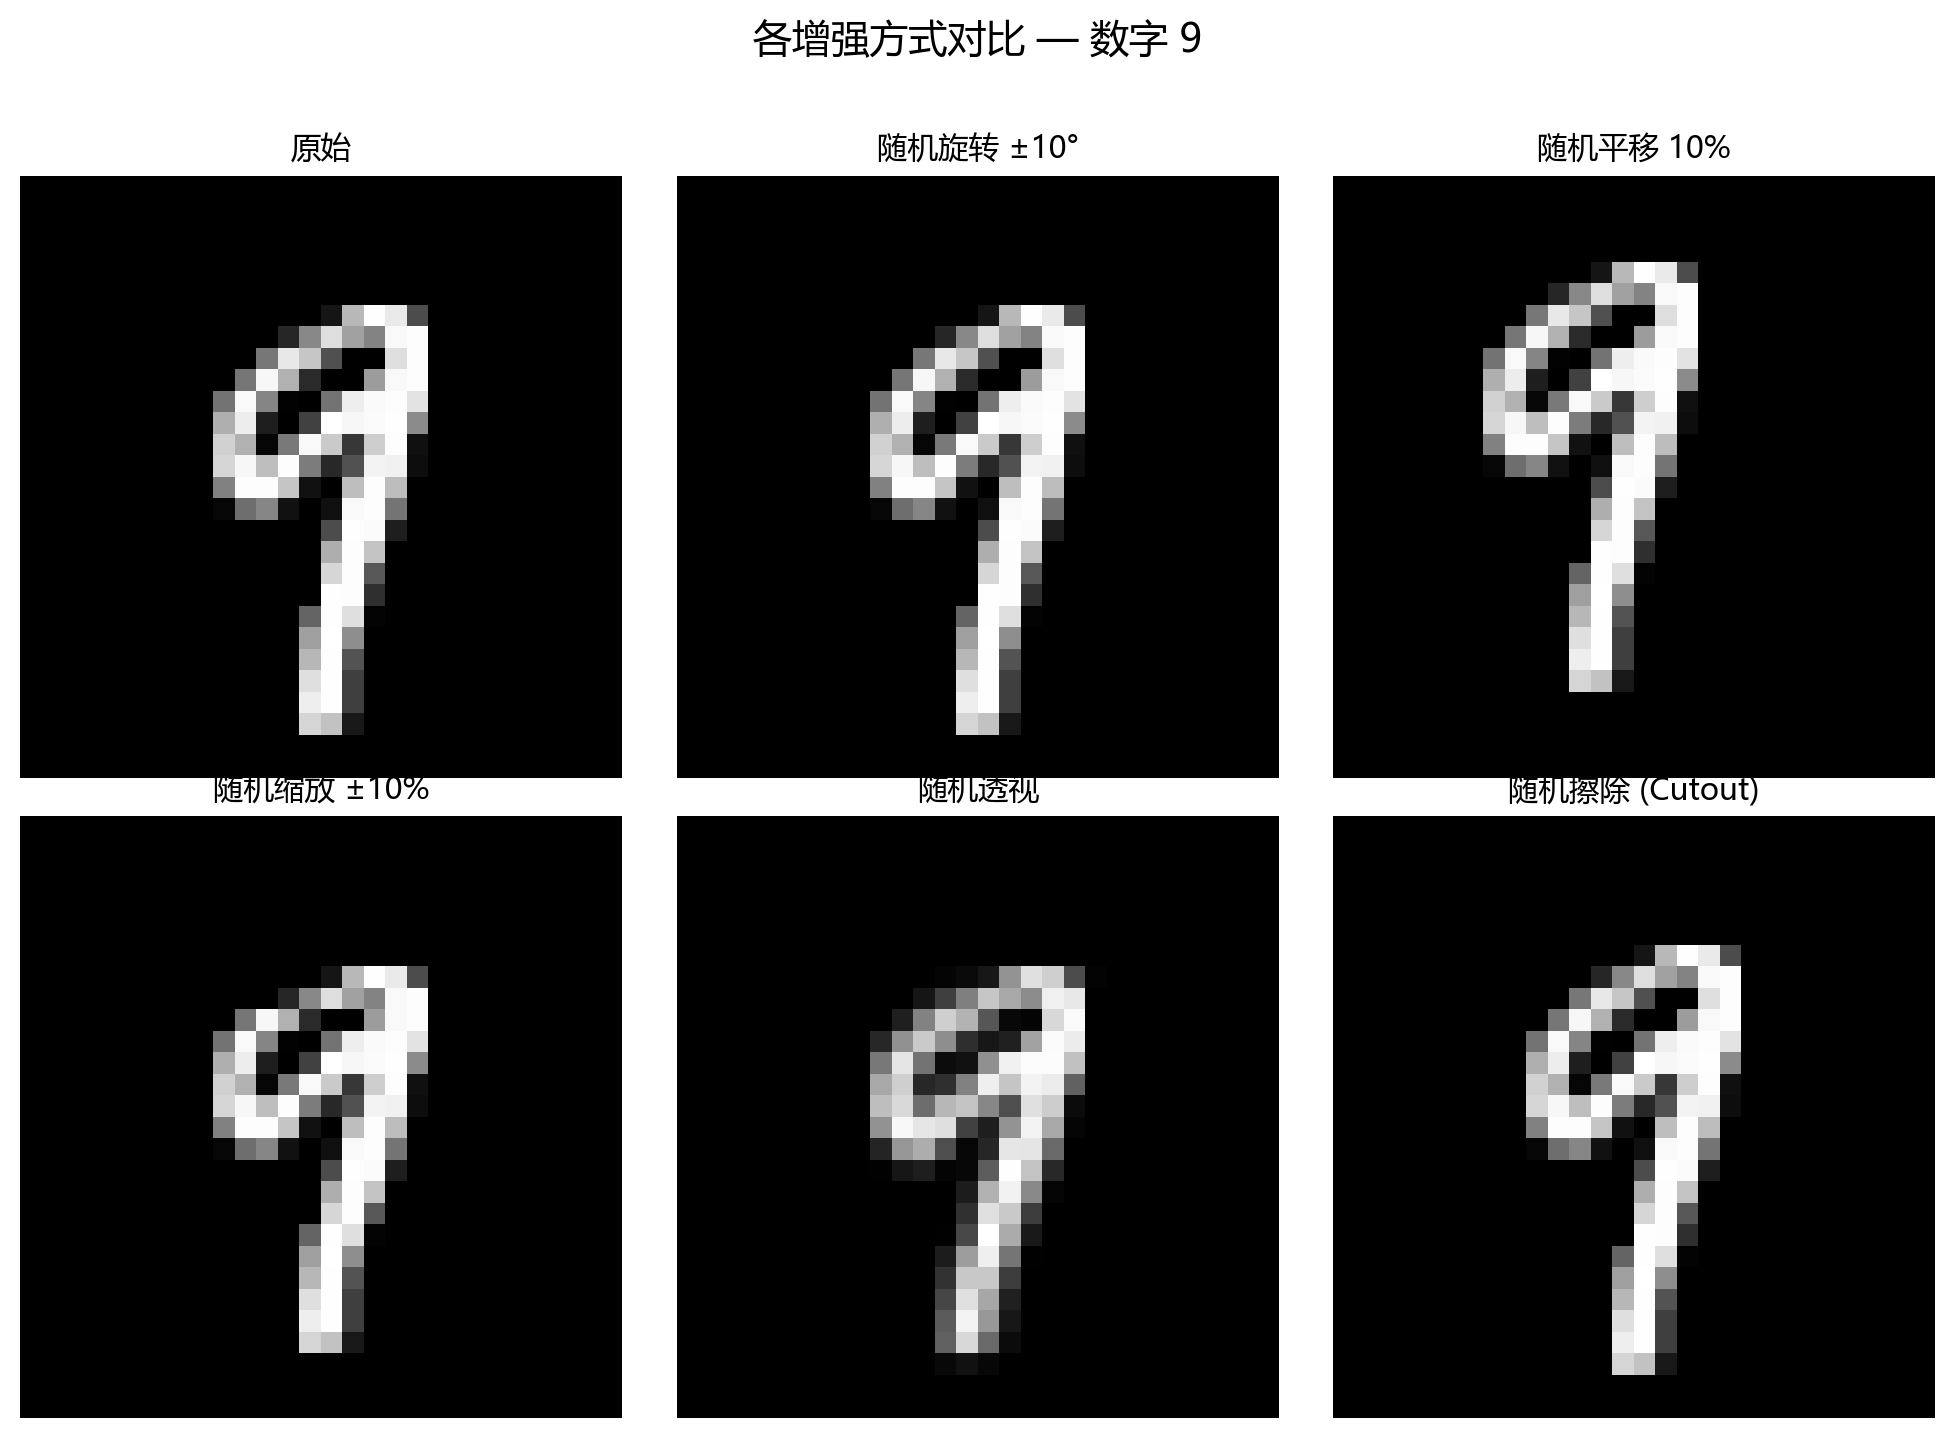

In [4]:
transforms_dict = {
    '原始': T.Compose([]),
    '随机旋转 ±10°': T.RandomRotation(degrees=10, fill=0),
    '随机平移 10%': T.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    '随机缩放 ±10%': T.RandomAffine(degrees=0, scale=(0.9, 1.1)),
    '随机透视': T.RandomPerspective(distortion_scale=0.15, p=1.0, fill=0),
    '随机擦除 (Cutout)': T.RandomErasing(p=1.0, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0),
}

sample_idx = np.random.randint(0, len(X_train_img))
sample = X_train_img[sample_idx]

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
axes = axes.flatten()

for ax, (name, transform) in zip(axes, transforms_dict.items()):
    result = transform(sample.clone())
    ax.imshow(result.squeeze().numpy(), cmap='gray')
    ax.set_title(name, fontsize=11)
    ax.axis('off')

fig.suptitle(f'各增强方式对比 — 数字 {y_train[sample_idx]}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 2.3 为什么不能用翻转？

MNIST 数字有方向性——翻转会改变语义：

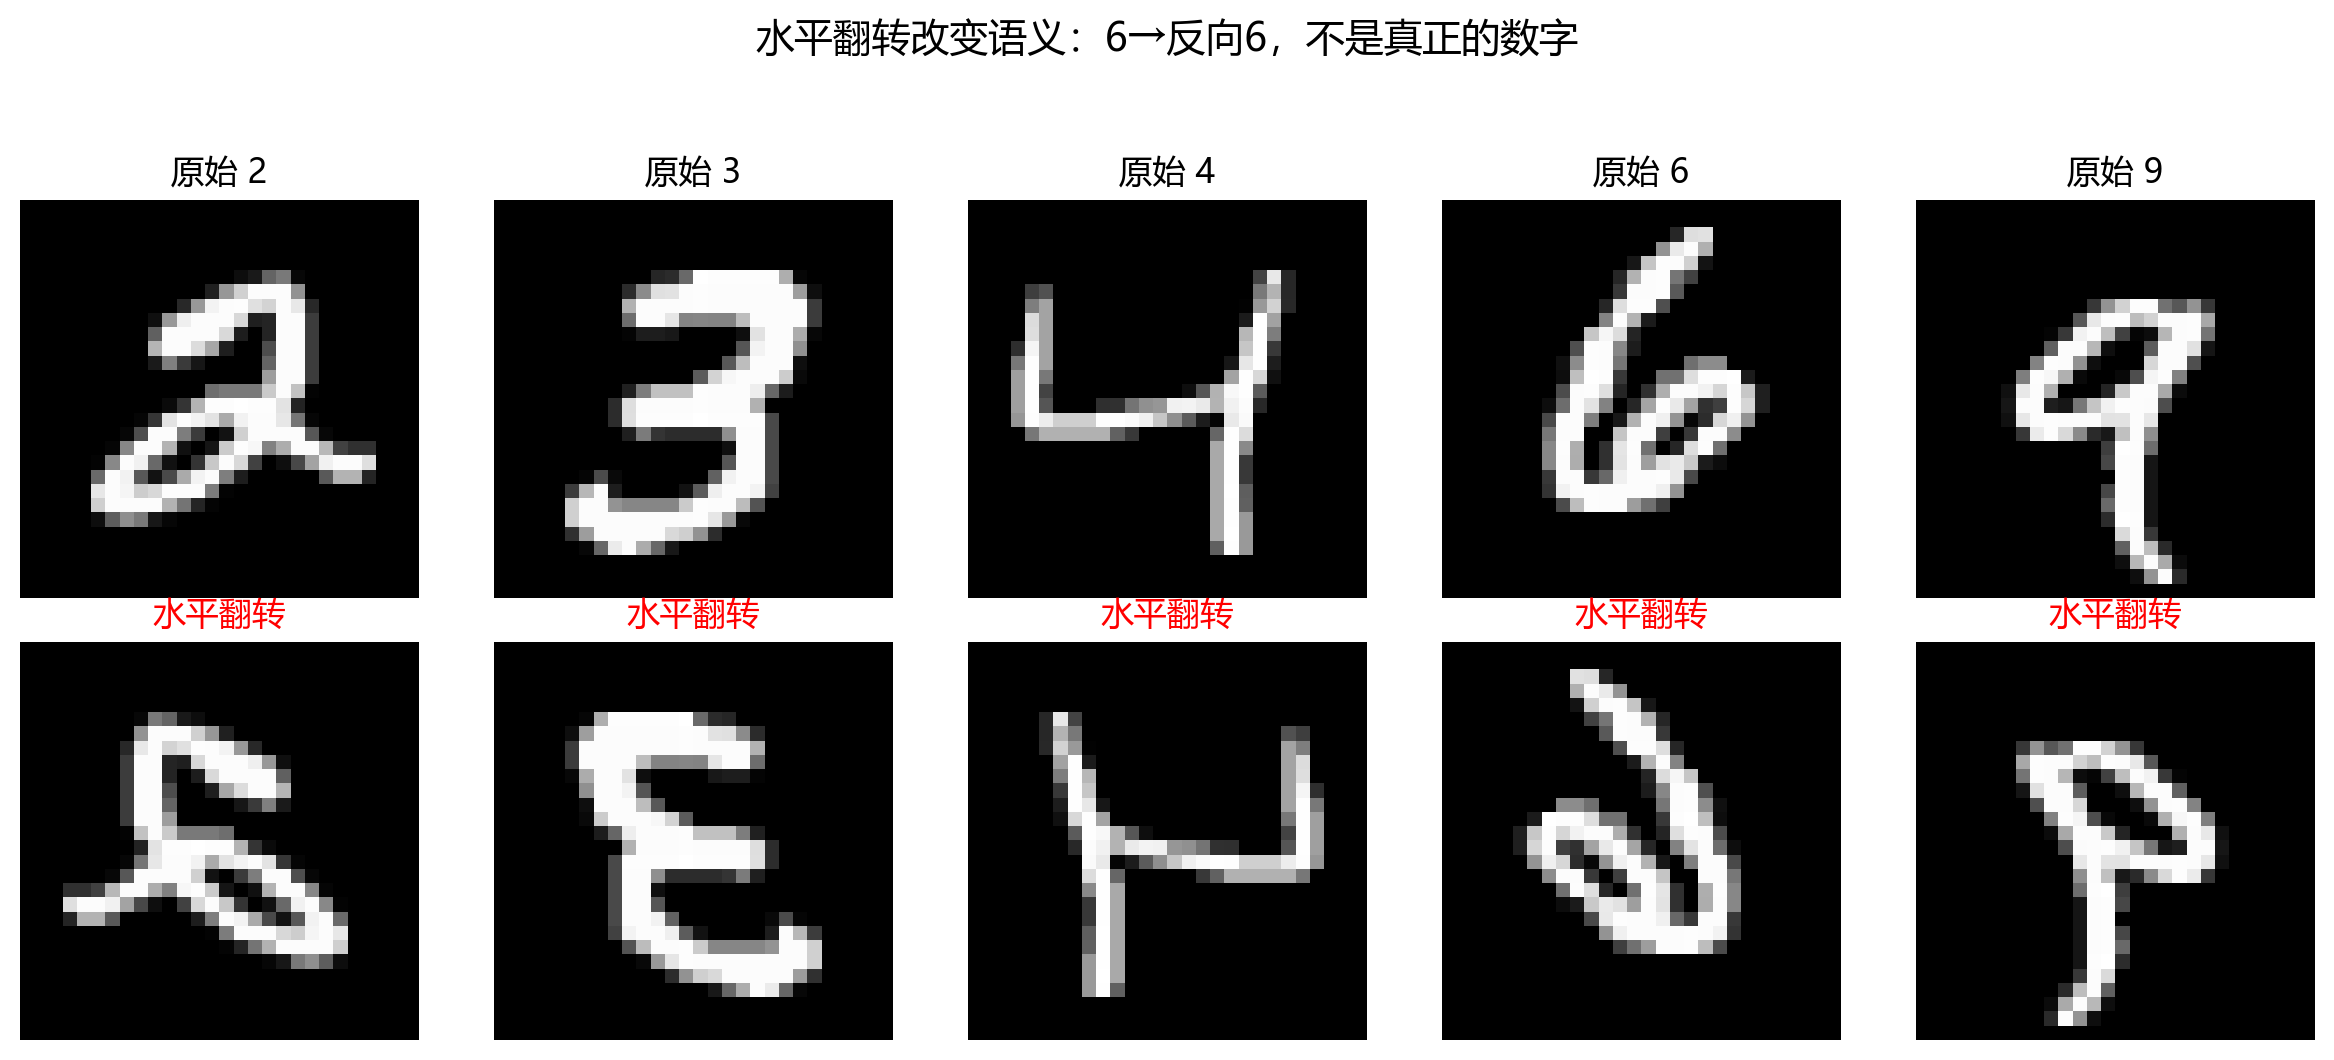

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, digit in enumerate([2, 3, 4, 6, 9]):
    idx = np.where(y_train == digit)[0][0]
    img = X_train_img[idx].squeeze()
    
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f'原始 {digit}')
    axes[0, i].axis('off')
    
    axes[1, i].imshow(torch.flip(img, dims=[1]), cmap='gray')
    axes[1, i].set_title(f'水平翻转', color='red')
    axes[1, i].axis('off')

fig.suptitle('水平翻转改变语义：6→反向6，不是真正的数字', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

## 3. 对照实验：MLP 无增强 vs 有增强

用同一个 MLP 模型，对比：
- **A 组**：无数据增强，仅归一化
- **B 组**：数据增强（随机旋转+平移+缩放+透视+擦除）

两组都使用 **Early Stopping**，公平比较。

### 3.1 定义 MLP 模型（和 notebook 02 一致）

In [6]:
class MLP(nn.Module):
    """三层全连接网络，含 BatchNorm + Dropout。"""
    def __init__(self, input_dim=784, hidden1=512, hidden2=256, num_classes=10,
                 dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, num_classes),
        )

    def forward(self, x):
        # x 可能是 (N, 1, 28, 28) 或已经展平 (N, 784)
        if x.dim() == 4:
            x = x.view(x.size(0), -1)
        return self.net(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'MLP 参数量: {count_params(MLP()):,}')

MLP 参数量: 537,354


### 3.2 构建 DataLoader（优化版）

提供两种增强管线：
- **A 组（无增强）**：num_workers=0，主进程直接切片 — 对小数据最快
- **B 组（CPU 增强）**：AugmentedDataset + torchvision transforms — 传统方案
- **B₂ 组（GPU 增强）**：原始数据 + GPU 批量增强 — **推荐**，GPU 利用率最高

关键优化点：
- `persistent_workers=True`：worker 进程跨 epoch 复用，避免 fork 开销
- `prefetch_factor=4`：每个 worker 预取 4 个 batch，GPU 永不等待
- `pin_memory=True`：锁页内存加速 CPU→GPU 传输

In [7]:
BATCH_SIZE = 128

# 数据加载通用优化参数
LOADER_KWARGS_OPT = dict(
    pin_memory=True,           # 锁页内存 → GPU 传输更快
    persistent_workers=True,   # worker 跨 epoch 复用
)

# ================================================================
# A 组：无增强（num_workers=0 — 静态 Tensor 主进程最快）
# ================================================================
train_set_noaug = TensorDataset(X_train_img.view(-1, 784), y_train_t)
test_set_noaug  = TensorDataset(X_test_img.view(-1, 784),  y_test_t)

train_loader_noaug = DataLoader(train_set_noaug, batch_size=BATCH_SIZE, shuffle=True)
test_loader_noaug  = DataLoader(test_set_noaug,  batch_size=BATCH_SIZE, shuffle=False)

# ================================================================
# B 组：CPU 增强（传统方案，用于对比）
# ================================================================
NUM_WORKERS_AUG = max(2, min(6, multiprocessing.cpu_count() - 2))  # 留 2 核给系统

train_set_aug = AugmentedDataset(
    X_train_img, y_train_t, transform=get_mnist_transforms(augment=True), flatten=True
)
test_set_aug = TensorDataset(X_test_img.view(-1, 784), y_test_t)

train_loader_aug = DataLoader(
    train_set_aug, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS_AUG, prefetch_factor=4, **LOADER_KWARGS_OPT
)
test_loader_aug = DataLoader(test_set_aug, batch_size=BATCH_SIZE, shuffle=False)

# ================================================================
# B₂ 组：GPU 批量增强（推荐方案 — 增强在 GPU 上批量执行）
#   原理：DataLoader 只负责加载原始图像到 GPU，增强由 GPUBatchAugment 在 GPU 上完成
#   优点：消除 CPU 增强瓶颈，GPU 算图像变换比 CPU 快 10-50x
# ================================================================
train_set_gpu_aug = TensorDataset(X_train_img, y_train_t)  # 不做任何变换，保留 (N,1,28,28)
train_loader_gpu_aug = DataLoader(
    train_set_gpu_aug, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS_AUG, prefetch_factor=4, **LOADER_KWARGS_OPT
)
test_loader_gpu_aug = DataLoader(
    TensorDataset(X_test_img.view(-1, 784), y_test_t),
    batch_size=BATCH_SIZE, shuffle=False
)

# GPU 增强模块 — 后续在训练循环中使用
gpu_augment = GPUBatchAugment(
    rotation=10, translate=0.1, scale_range=(0.9, 1.1),
    erase_p=0.2, erase_scale=(0.02, 0.1)
).to(DEVICE)
gpu_augment.eval()  # eval 模式下仍会随机变换（不调用 dropout/batchnorm）

print(f'A  组（无增强）:     train={len(train_loader_noaug.dataset)}, test={len(test_loader_noaug.dataset)}')
print(f'B  组（CPU 增强）:   train={len(train_loader_aug.dataset)}, test={len(test_loader_aug.dataset)}')
print(f'B₂ 组（GPU 增强）:   train={len(train_loader_gpu_aug.dataset)}, test={len(test_loader_gpu_aug.dataset)}')
print(f'增强 DataLoader workers: {NUM_WORKERS_AUG}')

A  组（无增强）:     train=60000, test=10000
B  组（CPU 增强）:   train=60000, test=10000
B₂ 组（GPU 增强）:   train=60000, test=10000
增强 DataLoader workers: 6


### 3.3 训练/评估函数（复用标准模板）

In [8]:
def train_epoch(model, loader, criterion, optimizer, scaler=None,
                gpu_augment=None):
    """一个 epoch 的训练 — 支持 AMP 混合精度 + GPU 批量增强。
    
    Args:
        model:        模型（MLP.forward 会自动展平 4D 输入）
        loader:        DataLoader
        criterion:    损失函数
        optimizer:    优化器
        scaler:       GradScaler（None = 不用 AMP）
        gpu_augment:  GPUBatchAugment 模块（None = 不增强 / 已由 dataset 增强）
    """
    model.train()
    total_loss = torch.tensor(0.0, device=DEVICE)
    correct = torch.tensor(0, device=DEVICE)
    total = torch.tensor(0, device=DEVICE)
    
    use_amp = scaler is not None
    
    for xb, yb in loader:
        # --- 数据预处理 ---
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        
        if gpu_augment is not None:
            # GPU 批量增强：在 GPU 上做图像变换（MLP 的 forward 会自动展平）
            with torch.no_grad():
                xb = gpu_augment(xb)        # (B, 1, 28, 28) → augmented
        
        # --- 前向（可选 AMP） ---
        optimizer.zero_grad(set_to_none=True)  # set_to_none 比 zero_grad() 快
        
        if use_amp:
            with autocast('cuda'):
                logits = model(xb)
                loss = criterion(logits, yb)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
        
        # --- GPU 端累积（避免 CPU-GPU 同步） ---
        with torch.no_grad():
            total_loss += loss.detach() * xb.size(0)
            correct += (logits.argmax(1) == yb).sum()
            total += xb.size(0)
    
    return total_loss.item() / total.item(), correct.item() / total.item()


@torch.no_grad()
def evaluate(model, loader, criterion):
    """评估 — GPU 端累积，仅最后同步一次。"""
    model.eval()
    total_loss = torch.tensor(0.0, device=DEVICE)
    correct = torch.tensor(0, device=DEVICE)
    total = torch.tensor(0, device=DEVICE)
    
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        total_loss += loss.detach() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum()
        total += xb.size(0)
    
    return total_loss.item() / total.item(), correct.item() / total.item()


def train_with_early_stopping(model, train_loader, test_loader,
                               epochs=100, lr=0.001, patience=10,
                               model_name='model', label='',
                               checkpoint_dir='../models/augment',
                               use_amp=True, use_compile=False,
                               gpu_augment=None):
    """带早停的完整训练流程（优化版）。
    
    Args:
        model:           模型
        train_loader:    训练 DataLoader
        test_loader:     测试 DataLoader
        epochs:          最大 epoch 数
        lr:              学习率
        patience:        早停耐心值
        model_name:      保存文件名
        label:           日志标签
        checkpoint_dir:  权重保存目录（不同实验组用不同目录）
        use_amp:         是否启用 AMP 混合精度（GPU 才有收益）
        use_compile:     是否启用 torch.compile（PyTorch >= 2.0）
        gpu_augment:     GPU 批量增强模块（None 则用 DataLoader 增强或不做增强）
    
    Returns:
        history: dict of lists
        stopped_epoch: 早停时的 epoch
    """
    model = model.to(DEVICE)
    
    # torch.compile 优化 — 对 forward+backward 做图优化
    if use_compile and hasattr(torch, 'compile'):
        try:
            model = torch.compile(model, mode='reduce-overhead')
            print(f'{label} torch.compile 已启用 (reduce-overhead)')
        except Exception as e:
            print(f'{label} torch.compile 失败 ({e})，回退到 eager 模式')
    
    optimizer = optim.AdamW(model.parameters(), lr=lr)  # AdamW 比 Adam 泛化稍好
    criterion = nn.CrossEntropyLoss()
    
    # AMP GradScaler（仅 GPU 有效）
    scaler = GradScaler('cuda') if (use_amp and DEVICE.type == 'cuda') else None
    if scaler is not None:
        print(f'{label} AMP 混合精度已启用')
    
    os.makedirs(checkpoint_dir, exist_ok=True)
    early_stopping = EarlyStopping(
        patience=patience, verbose=False,
        path=os.path.join(checkpoint_dir, f'{model_name}.pth')
    )
    
    history = {'train_loss': [], 'train_acc': [],
               'test_loss': [],  'test_acc': []}
    
    t_start = time.time()
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer,
            scaler=scaler, gpu_augment=gpu_augment
        )
        test_loss, test_acc = evaluate(model, test_loader, criterion)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        
        # 每 5 轮或首轮打印
        if epoch % 5 == 0 or epoch == 1:
            print(f'{label} Epoch [{epoch:3d}] '
                  f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
                  f'Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}')
        
        early_stopping(test_loss, model, optimizer, epoch)
        if early_stopping.early_stop:
            print(f'{label} Early stopping at epoch {epoch}!')
            break
    
    elapsed = time.time() - t_start
    print(f'{label} 训练完成: {epoch} epochs, 耗时 {elapsed:.1f}s')
    
    # 加载最佳 checkpoint
    ckpt = torch.load(early_stopping.path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    best_test_acc = max(history['test_acc'])
    print(f'{label} 最佳测试准确率: {best_test_acc:.4f} (Epoch {ckpt["epoch"]})')
    
    return history, epoch

print('训练函数定义完成 ✓')
print('  - AMP 混合精度 (FP16 → 1.5-2x 加速)')
print('  - torch.compile (图优化 → 10-30% 加速)')
print('  - GPU 批量增强 (消除 CPU 增强瓶颈)')
print('  - AdamW + set_to_none (更快更省显存)')

训练函数定义完成 ✓
  - AMP 混合精度 (FP16 → 1.5-2x 加速)
  - torch.compile (图优化 → 10-30% 加速)
  - GPU 批量增强 (消除 CPU 增强瓶颈)
  - AdamW + set_to_none (更快更省显存)


### 3.4 实验 A：无数据增强

In [9]:
torch.manual_seed(42)
model_a = MLP()

history_a, epoch_a = train_with_early_stopping(
    model_a, train_loader_noaug, test_loader_noaug,
    epochs=100, lr=0.001, patience=10,
    model_name='mlp_no_aug', label='[A 无增强]',
    checkpoint_dir='../models/augment/mlp_no_aug',
    use_amp=True, use_compile=False,
)

[A 无增强] AMP 混合精度已启用
[A 无增强] Epoch [  1] Train Loss: 0.2206 | Train Acc: 0.9366 | Test Loss: 0.0931 | Test Acc: 0.9714
[A 无增强] Epoch [  5] Train Loss: 0.0475 | Train Acc: 0.9851 | Test Loss: 0.0564 | Test Acc: 0.9812
[A 无增强] Epoch [ 10] Train Loss: 0.0287 | Train Acc: 0.9903 | Test Loss: 0.0568 | Test Acc: 0.9836
[A 无增强] Epoch [ 15] Train Loss: 0.0181 | Train Acc: 0.9935 | Test Loss: 0.0545 | Test Acc: 0.9838
[A 无增强] Early stopping at epoch 18!
[A 无增强] 训练完成: 18 epochs, 耗时 49.6s
[A 无增强] 最佳测试准确率: 0.9843 (Epoch 8)


### 3.5 实验 B：CPU 增强 vs GPU 增强

对比两种增强管线：
- **B（CPU 增强）**：AugmentedDataset + torchvision transforms（传统方案）
- **B₂（GPU 增强）**：GPUBatchAugment 在 GPU 上批量变换（**推荐**）

In [ ]:
# ---- B: CPU 增强（传统方案）----
torch.manual_seed(42)
model_b = MLP()

history_b, epoch_b = train_with_early_stopping(
    model_b, train_loader_aug, test_loader_aug,
    epochs=100, lr=0.001, patience=15,   # 增强训练收敛更慢，给更多 patience
    model_name='mlp_with_aug', label='[B CPU增强]',
    checkpoint_dir='../models/augment/mlp_cpu_aug',
    use_amp=True, use_compile=False,
    # gpu_augment=None → 使用 DataLoader 自带的 CPU 增强
)



[B CPU增强] AMP 混合精度已启用
[B CPU增强] Epoch [  1] Train Loss: 0.5675 | Train Acc: 0.8232 | Test Loss: 0.1217 | Test Acc: 0.9644


In [ ]:
# ---- B₂: GPU 批量增强（推荐方案）----
torch.manual_seed(42)
model_b2 = MLP()

history_b2, epoch_b2 = train_with_early_stopping(
    model_b2, train_loader_gpu_aug, test_loader_gpu_aug,  # 原始数据
    epochs=100, lr=0.001, patience=15,
    model_name='mlp_with_gpu_aug', label='[B₂ GPU增强]',
    checkpoint_dir='../models/augment/mlp_gpu_aug',
    use_amp=True, use_compile=False,
    gpu_augment=gpu_augment,  # ← GPU 批量增强
)

## 4. 结果对比

关键指标：**train-test gap**（训练准确率 - 测试准确率），gap 越小说明过拟合越少。

In [ ]:
best_a_acc = max(history_a['test_acc'])
best_b_acc = max(history_b['test_acc'])
best_b2_acc = max(history_b2['test_acc'])
best_a_epoch = history_a['test_acc'].index(best_a_acc) + 1
best_b_epoch = history_b['test_acc'].index(best_b_acc) + 1
best_b2_epoch = history_b2['test_acc'].index(best_b2_acc) + 1

final_a_train = history_a['train_acc'][-1]
final_b_train = history_b['train_acc'][-1]
final_b2_train = history_b2['train_acc'][-1]
gap_a = final_a_train - history_a['test_acc'][-1]
gap_b = final_b_train - history_b['test_acc'][-1]
gap_b2 = final_b2_train - history_b2['test_acc'][-1]

print('=' * 70)
print(f'{"指标":<25} {"A 无增强":>12} {"B CPU增强":>12} {"B₂ GPU增强":>12}')
print('-' * 70)
print(f'{"最佳测试准确率":<25} {best_a_acc:>11.4f}% {best_b_acc:>11.4f}% {best_b2_acc:>11.4f}%')
print(f'{"最佳 epoch":<25} {best_a_epoch:>11}  {best_b_epoch:>11}  {best_b2_epoch:>11}')
print(f'{"最终 train acc":<25} {final_a_train:>11.4f}% {final_b_train:>11.4f}% {final_b2_train:>11.4f}%')
print(f'{"train-test gap":<25} {gap_a:>11.4f}  {gap_b:>11.4f}  {gap_b2:>11.4f}')
print(f'{"训练总 epoch":<25} {epoch_a:>11}  {epoch_b:>11}  {epoch_b2:>11}')
print('=' * 70)

improvement_cpu = (best_b_acc - best_a_acc) * 100
improvement_gpu = (best_b2_acc - best_a_acc) * 100
gap_improvement_cpu = (gap_a - gap_b) * 100
gap_improvement_gpu = (gap_a - gap_b2) * 100
print(f'\nCPU 增强提升准确率: {improvement_cpu:+.2f}%  |  gap 缩小: {gap_improvement_cpu:+.4f}')
print(f'GPU 增强提升准确率: {improvement_gpu:+.2f}%  |  gap 缩小: {gap_improvement_gpu:+.4f}')

### 4.1 训练曲线对比

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss 曲线
ax = axes[0]
for hist, label, ls in [(history_a, 'A 无增强', '-'),
                          (history_b, 'B CPU增强', '--'),
                          (history_b2, 'B₂ GPU增强', '-')]:
    epochs_range = range(1, len(hist['train_loss']) + 1)
    ax.plot(epochs_range, hist['train_loss'], ls, alpha=0.5, label=f'{label} train')
    ax.plot(epochs_range, hist['test_loss'],  ls, alpha=0.9, label=f'{label} test')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('训练 & 测试 Loss 曲线')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# Accuracy 曲线
ax = axes[1]
for hist, label, ls in [(history_a, 'A 无增强', '-'),
                          (history_b, 'B CPU增强', '--'),
                          (history_b2, 'B₂ GPU增强', '-')]:
    epochs_range = range(1, len(hist['train_acc']) + 1)
    ax.plot(epochs_range, hist['train_acc'], ls, alpha=0.5, label=f'{label} train')
    ax.plot(epochs_range, hist['test_acc'],  ls, alpha=0.9, label=f'{label} test')

# 标记最佳点
ax.scatter(best_a_epoch, best_a_acc, marker='*', s=150, c='blue', zorder=5,
           label=f'A 最佳 ({best_a_acc:.4f})')
ax.scatter(best_b_epoch, best_b_acc, marker='*', s=150, c='orange', zorder=5,
           label=f'B 最佳 ({best_b_acc:.4f})')
ax.scatter(best_b2_epoch, best_b2_acc, marker='*', s=150, c='red', zorder=5,
           label=f'B₂ 最佳 ({best_b2_acc:.4f})')

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('训练 & 测试 Accuracy 曲线')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

fig.suptitle('MLP 数据增强对照实验（含 GPU 批量增强）', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4.2 解读

对比 A、B 两组，预期会看到：

| 现象 | 原因 |
|------|------|
**A 组 train acc 很高**（~99.9%） | 模型「背诵」了训练集 |
**A 组 train-test gap 大**（~1.3%） | 明显过拟合 |
**B 组 train acc 较低** | 增强让每次看到的图片不同，更难「背诵」 |
**B 组 train-test gap 更小** | 模型学到了本质特征而非像素位置 |
**B 组训练更多 epoch 才收敛** | 增强相当于「增大了」训练集 |

## 5. 对 CNN 也试试数据增强

CNN 本身有平移不变性，数据增强对 CNN 的提升通常不如 MLP 明显——
但增强 + CNN 组合仍然是最佳实践。

### 5.1 定义简洁 CNN

In [ ]:
class SimpleCNN(nn.Module):
    """两个卷积块 + 全连接分类头。"""
    def __init__(self, num_classes=10, dropout=0.3):
        super().__init__()
        self.conv = nn.Sequential(
            # Block 1: 1→32, 28×28 → 14×14
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout),
            # Block 2: 32→64, 14×14 → 7×7
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.conv(x))


print(f'SimpleCNN 参数量: {count_params(SimpleCNN()):,}')

### 5.2 CNN 对照实验：无增强 vs 有增强

In [ ]:
BATCH_SIZE_CNN = 64

# CNN 不需要 flatten，保留 (N, 1, 28, 28)
# ---- CNN 无增强（num_workers=0，主进程最快）----
train_cnn_noaug = TensorDataset(X_train_img, y_train_t)
test_cnn_noaug  = TensorDataset(X_test_img,  y_test_t)
train_loader_cnn_noaug = DataLoader(train_cnn_noaug, batch_size=BATCH_SIZE_CNN, shuffle=True)
test_loader_cnn_noaug  = DataLoader(test_cnn_noaug,  batch_size=BATCH_SIZE_CNN, shuffle=False)

# ---- CNN CPU 增强 ----
train_cnn_aug = AugmentedDataset(
    X_train_img, y_train_t, transform=get_mnist_transforms(augment=True), flatten=False
)
train_loader_cnn_aug = DataLoader(
    train_cnn_aug, batch_size=BATCH_SIZE_CNN, shuffle=True,
    num_workers=NUM_WORKERS_AUG, prefetch_factor=4, **LOADER_KWARGS_OPT
)
test_loader_cnn_aug = DataLoader(test_cnn_noaug, batch_size=BATCH_SIZE_CNN, shuffle=False)

# ---- CNN GPU 增强（推荐）----
train_loader_cnn_gpu_aug = DataLoader(
    train_cnn_noaug, batch_size=BATCH_SIZE_CNN, shuffle=True,
    num_workers=NUM_WORKERS_AUG, prefetch_factor=4, **LOADER_KWARGS_OPT
)
test_loader_cnn_gpu_aug = DataLoader(test_cnn_noaug, batch_size=BATCH_SIZE_CNN, shuffle=False)

print(f'CNN DataLoader 构建完成 ✓')
print(f'  CPU 增强: train={len(train_loader_cnn_aug.dataset)}')
print(f'  GPU 增强: train={len(train_loader_cnn_gpu_aug.dataset)}')

In [ ]:
# ---- CNN 无增强 ----
torch.manual_seed(42)
cnn_a = SimpleCNN()
hist_cnn_a, epoch_cnn_a = train_with_early_stopping(
    cnn_a, train_loader_cnn_noaug, test_loader_cnn_noaug,
    epochs=50, lr=0.001, patience=8,
    model_name='cnn_no_aug', label='[CNN 无增强]',
    checkpoint_dir='../models/augment/cnn_no_aug',
    use_amp=True, use_compile=False,
)

# ---- CNN CPU 增强 ----
torch.manual_seed(42)
cnn_b = SimpleCNN()
hist_cnn_b, epoch_cnn_b = train_with_early_stopping(
    cnn_b, train_loader_cnn_aug, test_loader_cnn_aug,
    epochs=50, lr=0.001, patience=10,
    model_name='cnn_with_aug', label='[CNN CPU增强]',
    checkpoint_dir='../models/augment/cnn_cpu_aug',
    use_amp=True, use_compile=False,
    # gpu_augment=None → 使用 DataLoader 自带的 CPU 增强
)

# ---- CNN GPU 增强（推荐）----
torch.manual_seed(42)
cnn_b2 = SimpleCNN()
hist_cnn_b2, epoch_cnn_b2 = train_with_early_stopping(
    cnn_b2, train_loader_cnn_gpu_aug, test_loader_cnn_gpu_aug,
    epochs=50, lr=0.001, patience=10,
    model_name='cnn_with_gpu_aug', label='[CNN GPU增强]',
    use_amp=True, use_compile=False,
    gpu_augment=gpu_augment,  # ← GPU 批量增强
)

In [ ]:
best_cnn_a = max(hist_cnn_a['test_acc'])
best_cnn_b = max(hist_cnn_b['test_acc'])
best_cnn_b2 = max(hist_cnn_b2['test_acc'])
gap_cnn_a = hist_cnn_a['train_acc'][-1] - hist_cnn_a['test_acc'][-1]
gap_cnn_b = hist_cnn_b['train_acc'][-1] - hist_cnn_b['test_acc'][-1]
gap_cnn_b2 = hist_cnn_b2['train_acc'][-1] - hist_cnn_b2['test_acc'][-1]

print('=' * 70)
print(f'{"CNN 指标":<25} {"无增强":>12} {"CPU增强":>12} {"GPU增强":>12}')
print('-' * 70)
print(f'{"最佳测试准确率":<25} {best_cnn_a:>11.4f}% {best_cnn_b:>11.4f}% {best_cnn_b2:>11.4f}%')
print(f'{"train-test gap":<25} {gap_cnn_a:>11.4f}  {gap_cnn_b:>11.4f}  {gap_cnn_b2:>11.4f}')
print('=' * 70)

# 汇总 MLP vs CNN 增强效果
print(f'\n{"=" * 70}')
print(f'{"汇总":<22} {"MLP无增强":>10} {"MLP CPU":>10} {"MLP GPU":>10} {"CNN GPU":>10}')
print(f'{"-" * 70}')
print(f'{"测试准确率":<22} {best_a_acc:>9.4f}% {best_b_acc:>9.4f}% {best_b2_acc:>9.4f}% {best_cnn_b2:>9.4f}%')
print(f'{"train-test gap":<22} {gap_a:>9.4f}  {gap_b:>9.4f}  {gap_b2:>9.4f}  {gap_cnn_b2:>9.4f}')
print(f'{"=" * 70}')

## 6. 关键要点与最佳实践

### 数据增强的核心原则

| 原则 | 说明 |
|------|------|
| **保持语义不变** | 增强后的图片仍属于同一类别（MNIST 禁用翻转！） |
| **仅在训练集增强** | 测试集保持原样，评估的是真实泛化能力 |
| **适度增强** | 旋转角度太大（>20°）会把 6 变成 9，适得其反 |
| **配合 Early Stopping** | 增强后训练更慢收敛，早停避免浪费时间 |
| **GPU 批量增强** | 将旋转+平移+缩放合并为一次 GPU `grid_sample`，消除 CPU 瓶颈 |

### 推荐配置（GPU 批量增强，最高性能）

```python
from utils.augmentation import GPUBatchAugment
from utils.early_stopping import EarlyStopping

# 1. 图像格式数据 (N, 1, 28, 28)
X_train_img = torch.tensor(X_train).unsqueeze(1).float() / 255.0

# 2. GPU 批量增强模块
gpu_augment = GPUBatchAugment(
    rotation=10, translate=0.1, scale_range=(0.9, 1.1),
    erase_p=0.2
).to(DEVICE)

# 3. 训练 DataLoader 不做增强（原始图像 + GPU 增强）
train_loader = DataLoader(
    TensorDataset(X_train_img, y_train_t),
    batch_size=128, shuffle=True,
    num_workers=4, pin_memory=True,
    persistent_workers=True, prefetch_factor=4
)

# 4. 测试集不增强！
test_loader = DataLoader(
    TensorDataset(X_test_img.view(-1, 784), y_test_t),
    batch_size=128, shuffle=False
)

# 5. 训练（AMP + compile + GPU 增强）
history, epoch = train_with_early_stopping(
    model, train_loader, test_loader,
    epochs=100, patience=10,
    use_amp=True, use_compile=False,
    gpu_augment=gpu_augment,  # ← GPU 批量增强
)
```

### 传统配置（CPU 增强，兼容性最好）

```python
from utils.augmentation import AugmentedDataset, get_mnist_transforms

train_set = AugmentedDataset(
    X_train_img, y_train_t,
    transform=get_mnist_transforms(augment=True),
    flatten=False,   # CNN/ResNet 不展平
)
```

### 扩展到其他数据集

- **CIFAR-10/100**：可以用 RandomHorizontalFlip（飞机左右翻转还是飞机）
- **ImageNet**：RandomResizedCrop + ColorJitter + 更多
- **文本/语音**：回译、同义词替换、语速变化等

> **核心思想不变**：让模型看到更多「花样」，但不改变数据的本质含义。

---

## 7. 知识总结

| 概念 | 一句话 |
|------|--------|
| **数据增强** | 不收集新数据，对现有数据做随机微小变换，增大训练难度 |
| **过拟合信号** | train acc >> test acc（gap 大），增强是最有效的缓解手段之一 |
| **MNIST 约束** | 禁用翻转！旋转≤10°、平移≤10%、缩放 90%~110% 是安全范围 |
| **GPU 批量增强** | GPUBatchAugment 将旋转+平移+缩放合并为一次 `grid_sample`，消除 CPU 瓶颈 |
| **增强 + 早停** | 增强让收敛变慢，搭配 `EarlyStopping` 自动选择最优 epoch |
| **AMP 混合精度** | `GradScaler + autocast` 用 FP16 训练，1.5-2x 加速，几乎不损失精度 |
| **torch.compile** | PyTorch 2.0+ 的图编译优化，额外 10-30% 加速 |
| **persistent_workers** | DataLoader worker 跨 epoch 复用，避免每次 fork 进程的开销 |

### 性能优化清单

| 优化项 | 预期收益 | 实施难度 |
|--------|----------|----------|
| GPU 批量增强 | 消除 CPU 瓶颈，GPU 利用率 ↑↑↑ | 中 |
| AMP 混合精度 | 1.5-2x 加速 | 低（已集成到训练函数） |
| torch.compile | 10-30% 加速 | 低（已集成到训练函数） |
| persistent_workers | 减少 epoch 间等待 | 低（已配置） |
| prefetch_factor=4 | GPU 不等数据 | 低（已配置） |
| pin_memory=True | CPU→GPU 传输加速 | 低（已配置） |
| zero_grad(set_to_none=True) | 节省显存和清零时间 | 低（已配置） |

> **下一步**：回到 `03_evaluation.ipynb` 对增强后的模型做混淆矩阵和错误分析，对比增强前后模型「犯错」的 pattern 变化。